# Top-line desktop DAU: April (w/ headwinds) vs June (no headwinds) vs actuals

All series are **desktop legacy_desktop, country=ALL, segment=ALL, ex-Iran**, 28-day trailing MA.

- **April forecast (adj-h)**: `data-official/2026-04/.../mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet` + headwind spec `data-official/2026-04/adjustments/headwind.json` (linear ramp, -1,497,870 by 2026-12-15).
- **June forecast (raw)**: `data-official/2026-06/desktop_cps0.15983_thresh050_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet` (threshold-aligned variant). No headwind applied.
- **Actuals**: training rows from the June parquet (snapshot through `training_end_date` = 2026-05-15).

In [1]:
# setup
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from mozaic_daily.adjustments import (
    apply_net_adjustment_to_series,
    load_adjustments_from_dir,
    load_forecast,
)

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozai

In [2]:
# constants
APRIL_FORECAST_START = pd.Timestamp("2026-04-01")
JUNE_FORECAST_START = pd.Timestamp("2026-05-17")

APRIL_DESKTOP_RAW = "data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6/mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet"
APRIL_ADJUSTMENTS_DIR = "data-official/2026-04/adjustments"

JUNE_DESKTOP_RAW = "data-official/2026-06/desktop_cps0.15983_thresh050_recent13_clip0.6_cap426/mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet"

DESKTOP_FILTER = dict(
    data_source="legacy_desktop",
    segment='{"os": "ALL"}',
    app_name="desktop",
    country="ALL",
)

PLOT_START = pd.Timestamp("2026-01-01")
PLOT_END = pd.Timestamp("2026-12-31")


In [3]:
# helpers
def world_daily_desktop(df: pd.DataFrame) -> pd.DataFrame:
    """Filter to desktop-ALL world rows; return DataFrame indexed by target_date."""
    mask = pd.Series(True, index=df.index)
    for col, val in DESKTOP_FILTER.items():
        mask &= df[col] == val
    sub = df.loc[mask, ["target_date", "data_type", "dau"]].copy()
    sub["target_date"] = pd.to_datetime(sub["target_date"])
    return sub.set_index("target_date").sort_index()


def to_28ma(series: pd.Series) -> pd.Series:
    return series.sort_index().rolling(28).mean()


In [4]:
# load-april
april_df, april_meta = load_forecast(APRIL_DESKTOP_RAW)
april_daily = world_daily_desktop(april_df)
april_ma_raw = to_28ma(april_daily["dau"])

# Apply headwind adjustment to the forecast portion (>= forecast_start).
april_adjustments = load_adjustments_from_dir(APRIL_ADJUSTMENTS_DIR, april_ma_raw.index)
april_ma_with_h = apply_net_adjustment_to_series(
    april_ma_raw,
    april_adjustments,
    platform="desktop",
    forecast_start=APRIL_FORECAST_START,
)

print(f"April training rows end: {april_daily[april_daily['data_type']=='training'].index.max().date()}")
print(f"April forecast rows: {april_daily[april_daily['data_type']=='forecast'].index.min().date()} -> {april_daily[april_daily['data_type']=='forecast'].index.max().date()}")
print(f"Headwind on 2026-12-15: {april_adjustments['desktop'].loc['2026-12-15']:+,.0f}")


April training rows end: 2026-03-31
April forecast rows: 2026-04-01 -> 2027-12-31
Headwind on 2026-12-15: -1,497,870


In [5]:
# load-june
june_df, june_meta = load_forecast(JUNE_DESKTOP_RAW)
june_daily = world_daily_desktop(june_df)
june_ma_raw = to_28ma(june_daily["dau"])

print(f"June training rows end: {june_daily[june_daily['data_type']=='training'].index.max().date()}")
print(f"June forecast rows: {june_daily[june_daily['data_type']=='forecast'].index.min().date()} -> {june_daily[june_daily['data_type']=='forecast'].index.max().date()}")


June training rows end: 2026-05-16
June forecast rows: 2026-05-17 -> 2027-12-31


In [6]:
# actuals
# Use the June parquet's training rows as our actuals source (most recent
# snapshot, extending through training_end_date).
actuals_daily = june_daily.loc[june_daily["data_type"] == "training", "dau"].sort_index()
actuals_ma = to_28ma(actuals_daily)

print(f"Actuals daily: {actuals_daily.index.min().date()} -> {actuals_daily.index.max().date()}")
print(f"Actuals 28d MA last value ({actuals_ma.dropna().index.max().date()}): {actuals_ma.dropna().iloc[-1]:,.0f}")


Actuals daily: 2020-01-01 -> 2026-05-16
Actuals 28d MA last value (2026-05-16): 48,172,365


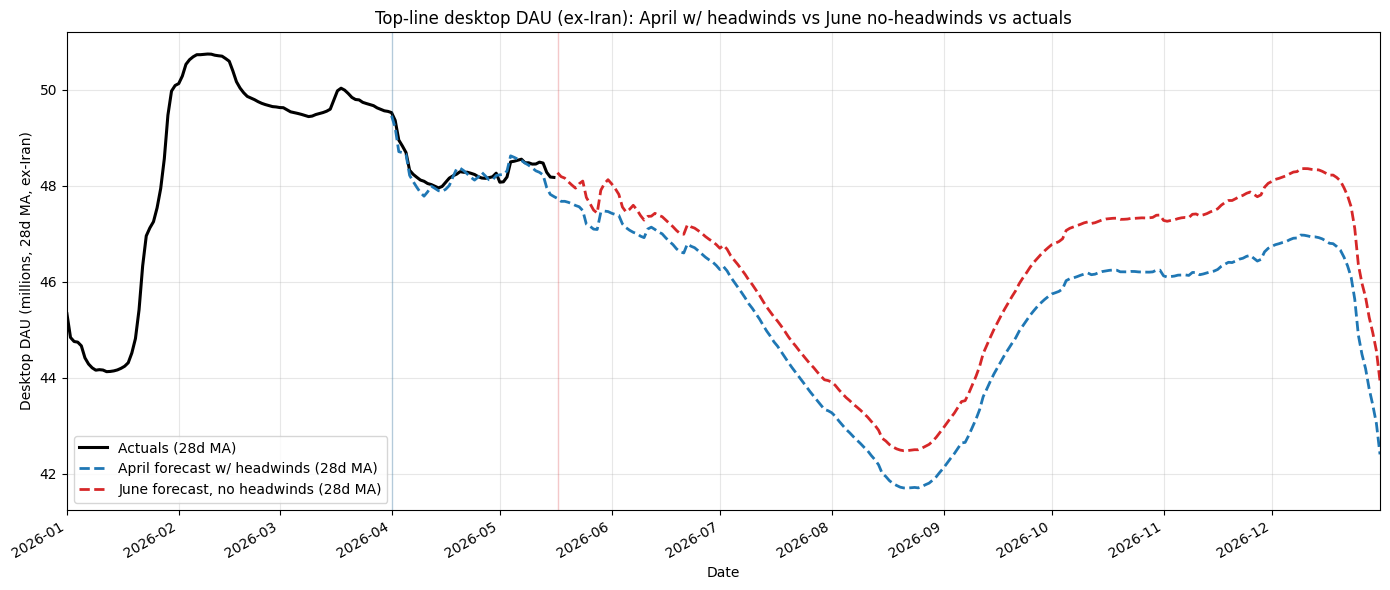

In [7]:
# plot
fig, ax = plt.subplots()

# Actuals: full visible portion.
actuals_window = actuals_ma.loc[PLOT_START:PLOT_END]
ax.plot(actuals_window.index, actuals_window.values / 1e6,
        color="black", linewidth=2.2, label="Actuals (28d MA)")

# April forecast WITH headwinds: forecast portion only (>= 2026-04-01).
april_fcst = april_ma_with_h.loc[APRIL_FORECAST_START:PLOT_END]
ax.plot(april_fcst.index, april_fcst.values / 1e6,
        color="#1f77b4", linewidth=2.0, linestyle="--",
        label="April forecast w/ headwinds (28d MA)")

# June forecast WITHOUT headwinds: forecast portion only (>= 2026-05-17).
june_fcst = june_ma_raw.loc[JUNE_FORECAST_START:PLOT_END]
ax.plot(june_fcst.index, june_fcst.values / 1e6,
        color="#d62728", linewidth=2.0, linestyle="--",
        label="June forecast, no headwinds (28d MA)")

# Vertical guides at each forecast start.
ax.axvline(APRIL_FORECAST_START, color="#1f77b4", alpha=0.25, linewidth=1)
ax.axvline(JUNE_FORECAST_START, color="#d62728", alpha=0.25, linewidth=1)

ax.set_xlim(PLOT_START, PLOT_END)
ax.set_xlabel("Date")
ax.set_ylabel("Desktop DAU (millions, 28d MA, ex-Iran)")
ax.set_title("Top-line desktop DAU (ex-Iran): April w/ headwinds vs June no-headwinds vs actuals")
ax.legend(loc="lower left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [8]:
# summary-table
checkpoint_dates = [
    pd.Timestamp("2026-05-15"),  # last actual
    pd.Timestamp("2026-06-30"),
    pd.Timestamp("2026-09-30"),
    pd.Timestamp("2026-12-15"),  # headwind anchor
    pd.Timestamp("2026-12-31"),
]

rows = []
for d in checkpoint_dates:
    rows.append({
        "date": d.date(),
        "actuals_28ma": actuals_ma.get(d),
        "april_adj_h_28ma": april_ma_with_h.get(d),
        "june_raw_28ma": june_ma_raw.get(d),
        "april_minus_june": (april_ma_with_h.get(d) or float("nan")) - (june_ma_raw.get(d) or float("nan")),
    })

summary = pd.DataFrame(rows).set_index("date")
summary_fmt = summary.copy()
for col in summary_fmt.columns:
    summary_fmt[col] = summary_fmt[col].apply(lambda v: f"{v:,.0f}" if pd.notna(v) else "—")
summary_fmt


,actuals_28ma,april_adj_h_28ma,june_raw_28ma,april_minus_june
date,,,,
2026-05-15,"48,180,345","47,817,868","48,180,345","-362,477"
2026-06-30,—,"46,338,754","46,773,359","-434,605"
2026-09-30,—,"45,687,453","46,707,674","-1,020,221"
2026-12-15,—,"46,891,136","48,299,293","-1,408,157"
2026-12-31,—,"42,400,446","43,927,678","-1,527,232"
